# Libraries

In [46]:
import pandas as pd 
!pip install pandas mysql-connector-python
import numpy as np


In [154]:
import seaborn as sns 
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Connecting MySql Server 

In [16]:
## Connecting Mysql server 
import mysql.connector

conn = {
    'host': 'localhost',
    'user': 'root',       # MySQL username
    'password': 'Dp7490901596',   # MySQL password
    'database': 'e_master_card'      # Database name
}
conn = mysql.connector.connect(**conn)

# Reading Tables 

In [145]:
## Tables
df_cus = pd.read_sql('select * from customers', conn)
df_credit = pd.read_sql('select * from credit_profiles', conn)
df_Avg = pd.read_sql('select * from avg_transactions_after_campaign', conn)
df_t = pd.read_sql('select * from transactions', conn)


/var/folders/_c/b2w3gm952076xb2j097hc0sc0000gn/T/ipykernel_46011/2246363084.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cus = pd.read_sql('select * from customers', conn)
/var/folders/_c/b2w3gm952076xb2j097hc0sc0000gn/T/ipykernel_46011/2246363084.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_credit = pd.read_sql('select * from credit_profiles', conn)
/var/folders/_c/b2w3gm952076xb2j097hc0sc0000gn/T/ipykernel_46011/2246363084.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_Avg = pd.read_sql('select

# 3. Preparing Customer Table

In [125]:
## checking dataframe cutsomers
df_cus.head(5)
df_cus.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,132439.799000
std,288.819436,15.666155,113706.313793
min,1.000000,1.000000,0.000000
25%,250.750000,26.000000,42229.750000
50%,500.500000,32.000000,107275.000000
75%,750.250000,46.000000,189687.500000
max,1000.000000,135.000000,449346.000000


In [127]:
## checking null values in customers
df_cus.isnull().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

In [146]:
df_cus['annual_income'] = df_cus['annual_income'].replace(0, np.nan)

In [147]:
## checking null values 
df_cus.isnull().sum()

cust_id            0
name               0
gender             0
age                0
location           0
occupation         0
annual_income     50
marital_status     0
dtype: int64

In [140]:
## printing null values 
df_cus[df_cus['annual_income'].isnull()]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Sanjana Malik,Female,25,Rural,Artist,NaN,Married
82,83,Reyansh Mukherjee,Male,27,City,Freelancer,NaN,Single
97,98,Virat Puri,Male,47,Suburb,Business Owner,NaN,Married
102,103,Aarav Shah,Male,32,City,Data Scientist,NaN,Married
155,156,Kiaan Saxena,Male,24,City,Fullstack Developer,NaN,Married
170,171,Advait Verma,Male,52,City,Business Owner,NaN,Single
186,187,Samar Sardar,Male,53,City,Consultant,NaN,Single
192,193,Ishan Joshi,Male,37,Suburb,Data Scientist,NaN,Married
227,228,Advait Mukherjee,Male,48,City,Business Owner,NaN,Married
232,233,Aditya Goel,Male,26,City,Freelancer,NaN,Married


In [148]:
## handling null values 

## grouping occuption 
 
grouped_o = df_cus.groupby('occupation').annual_income.median()

## replacing nan with median based on occupation
df_cus['annual_income'] = df_cus.apply
(lambda row :grouped_o[row['occupation']]if pd.isnull(row['annual_income']) else row['annual_income'], axis = 1)


In [150]:
## checking null values 
df_cus.isnull().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

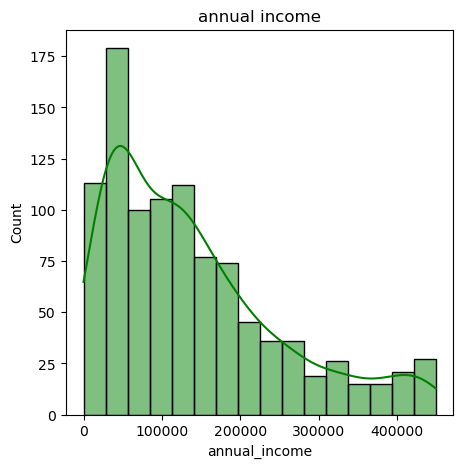

In [158]:
## checking distrubition of data using histogram 

plt.figure(figsize = (5,5))
sns.histplot(df_cus['annual_income'], color = 'green', kde = True, label = 'data')
plt.title('annual income')
plt.show

In [162]:
## Replacing income less then 100 with meadian values 
df_cus['annual_income'] = df_cus.apply(lambda row :grouped_o[row['occupation']] if row['annual_income'] < 100 else row['annual_income'], axis =1)

In [163]:
df_cus[df_cus['annual_income'] < 100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


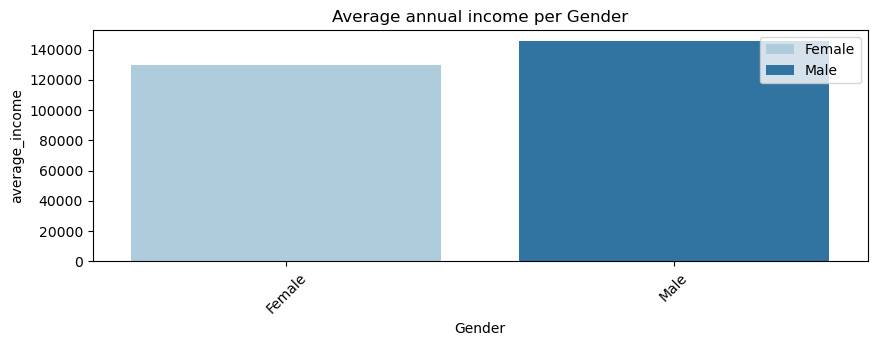

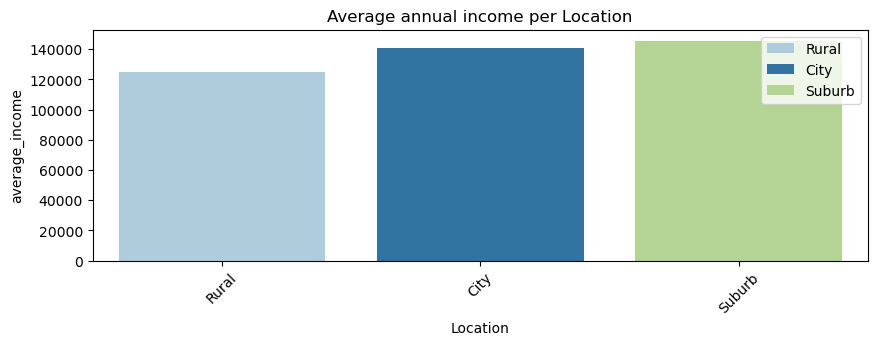

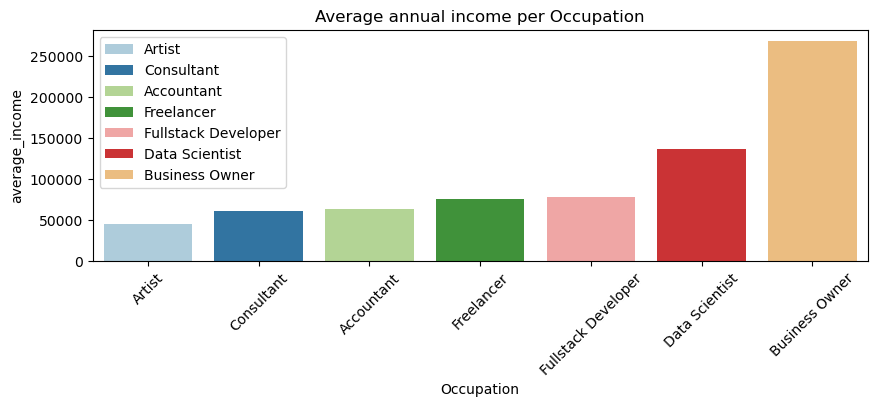

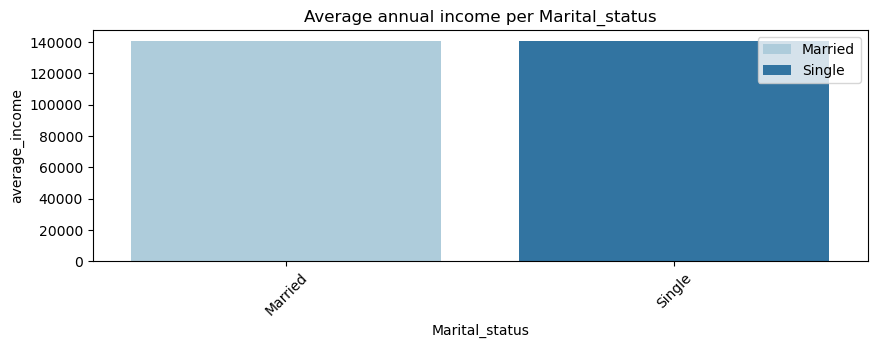

In [191]:
## visluaizing annual_income
categorical_column = ['gender','location','occupation','marital_status']

for col in categorical_column :
    average_income_bygroup = df_cus.groupby(col)['annual_income'].mean().sort_values()
    plt.figure(figsize=(10, 3))
    sns.barplot(x=average_income_bygroup.index, y=average_income_bygroup.values, palette='Paired', label=average_income_bygroup.index)
    plt.title(f'Average annual income per {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('average_income')
    plt.xticks(rotation=45)  # Optional: Rotate x-axis labels if needed
    plt.legend()
    plt.show()

In [212]:
## Treating outliner value in age 
outliner = df_cus[(df_cus.age < 15) | (df_cus.age > 80)]

print(type(outliner))

<class 'pandas.core.frame.DataFrame'>


In [204]:
Median_age = df_cus.groupby('occupation')['age'].median()
Median_age

occupation
Accountant             31.5
Artist                 26.0
Business Owner         51.0
Consultant             46.0
Data Scientist         32.0
Freelancer             24.0
Fullstack Developer    27.5
Name: age, dtype: float64

In [213]:
for index , row in outliner.iterrows() :
    df_cus.at[index, 'age']= Median_age[row['occupation']]

In [215]:
df_cus.age.describe()

count    1000.000000
mean       35.541500
std        12.276634
min        18.000000
25%        26.000000
50%        32.000000
75%        44.250000
max        64.000000
Name: age, dtype: float64

<Axes: xlabel='age', ylabel='Count'>

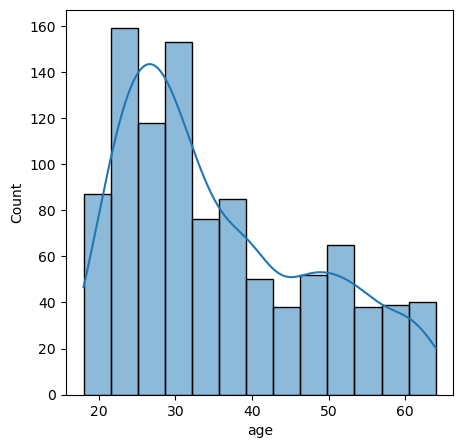

In [220]:
plt.figure(figsize = (5,5))
sns.histplot(df_cus['age'], kde=True)

In [222]:
## creating new column for age group 

bin_edges = [17,25,48,65]
bin_labels = ['18-25','26-48','49-65']

df_cus['age_group'] = pd.cut(df_cus['age'], bins = bin_edges , labels = bin_labels)

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
0,1,Manya Acharya,Female,51.0,City,Business Owner,358211.0,Married,49-65
1,2,Anjali Pandey,Female,47.0,City,Consultant,65172.0,Single,26-48
2,3,Aaryan Chauhan,Male,21.0,City,Freelancer,22378.0,Married,18-25
3,4,Rudra Bali,Male,24.0,Rural,Freelancer,33563.0,Married,18-25
4,5,Advait Malik,Male,48.0,City,Consultant,39406.0,Married,26-48
...,...,...,...,...,...,...,...,...,...
995,996,Manya Vasudeva,Female,26.0,City,Freelancer,46759.0,Married,26-48
996,997,Aarav Dhawan,Male,55.0,City,Business Owner,290061.0,Single,49-65
997,998,Rehan Jha,Male,29.0,City,Fullstack Developer,139141.0,Married,26-48
998,999,Amara Rathore,Female,47.0,City,Business Owner,261191.5,Married,26-48


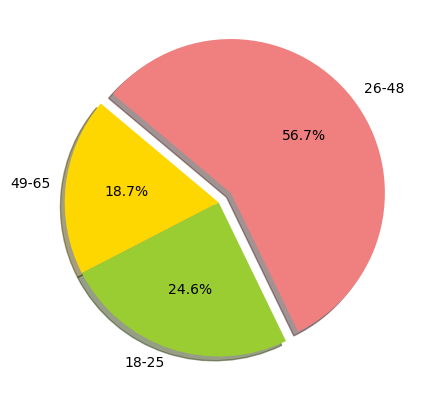

In [249]:
age_group_count = df_cus['age_group'].value_counts().sort_values()
plt.figure(figsize = (5,5))
plt.pie(age_group_count,
        autopct='%1.1f%%', 
        labels=age_group_count.index, 
        startangle=140, 
        colors=['gold', 'yellowgreen', 'lightcoral', 'skyblue', 'orange'],
        shadow =True,
        explode = (0,0,0.1)
       )
plt.show()


Text(0, 0.5, 'Count')

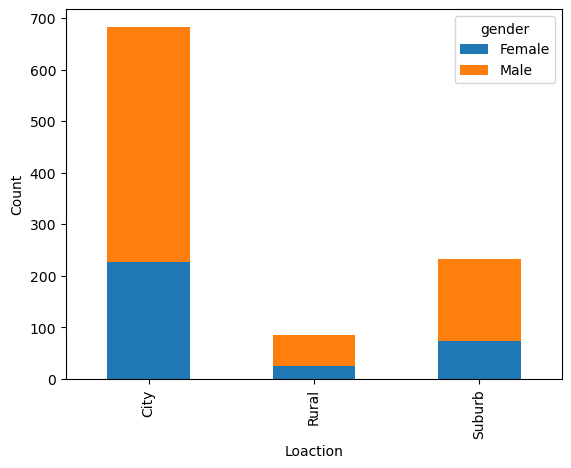

In [267]:
customer_location_gender = df_cus.groupby(['location','gender']).size().unstack()
customer_location_gender.plot(kind = 'bar', stacked = True)
plt.xlabel('Loaction')
plt.ylabel('Count')

# 2. Preapring Credit table 

In [263]:
df_credit.head(5)


,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [268]:
## checking for duplicate values 
df_credit['cust_id'].nunique()


<bound method Series.duplicated of 0          1
1          2
2          3
3          4
4          5
        ... 
999      996
1000     997
1001     998
1002     999
1003    1000
Name: cust_id, Length: 1004, dtype: int64>

In [279]:
## droping duplicate values
df_credit = df_credit.drop_duplicates(subset= 'cust_id' , keep = 'last')

In [280]:
df_credit.shape 

(1000, 6)

In [323]:
## checking null values
null_values = df_credit[df_credit['credit_limit'].isnull()]

In [286]:
df_credit.credit_limit.value_counts()

500.0      229
60000.0    186
40000.0    137
1500.0     100
1000.0      90
750.0       76
1250.0      75
20000.0     42
Name: credit_limit, dtype: int64

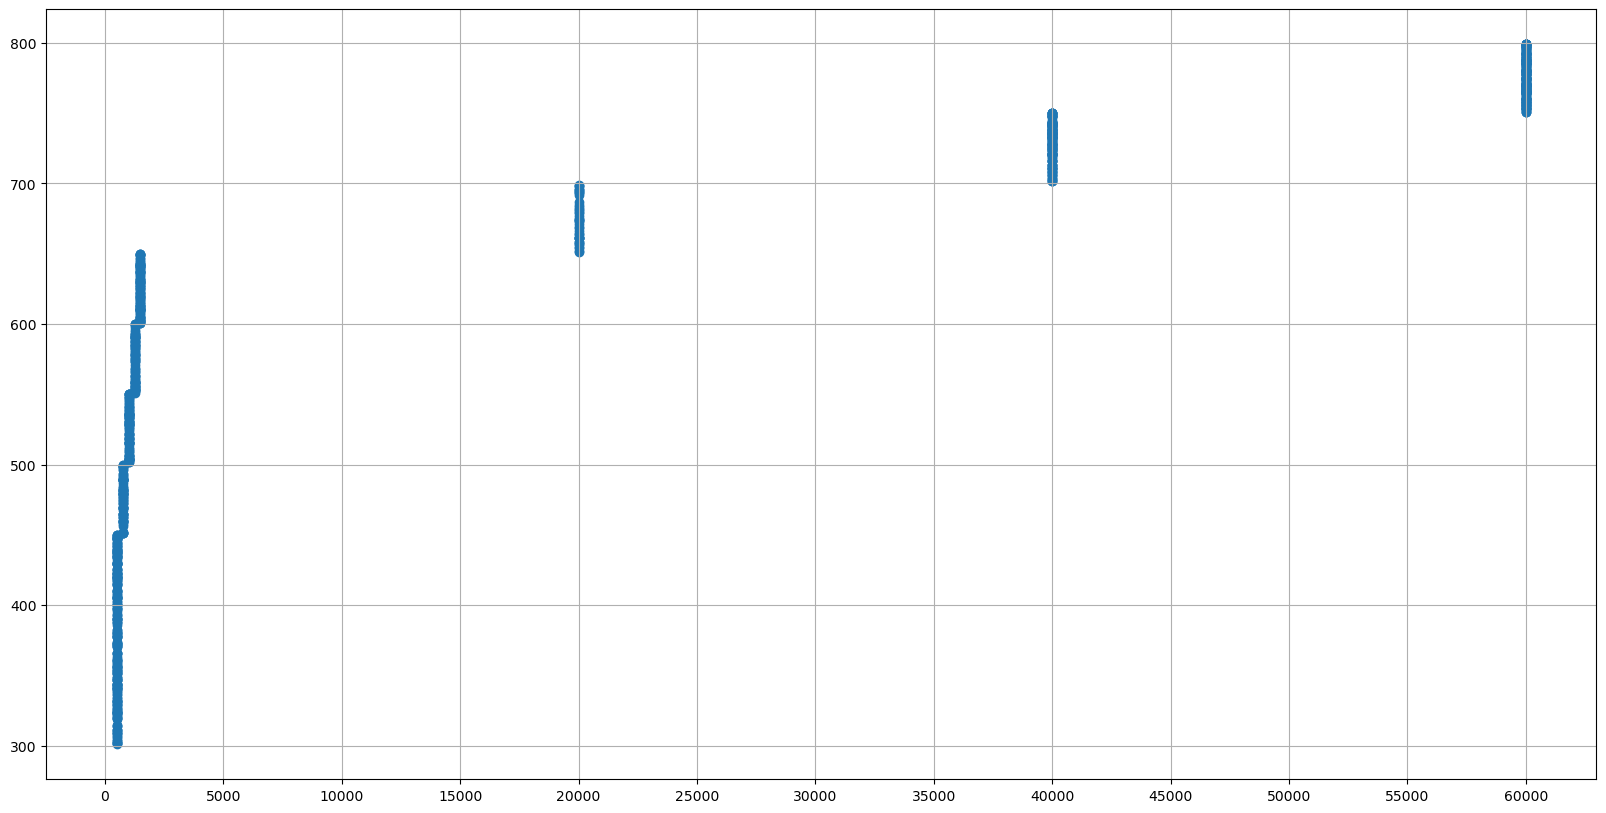

In [295]:
## checking relation between credit limt and score 
plt.figure(figsize = (20,10))
plt.scatter(df_credit.credit_limit,df_credit.credit_score)
plt.xticks(np.arange(0, max(df_credit.credit_limit) + 5000, 5000))
plt.grid(True)


In [366]:
## grouping the credit_score 
edges = [299,350,400,450,500,550,600,650,700,750,800]
labels = ['300-349','350-399','400-449','450-499','500-549','550-599','600-649','650-699','700-749','750-800']
df_credit['credit_score_range'] = pd.cut(df_credit['credit_score'], bins = edges, labels = labels)

In [370]:
## getting mode to replace the null values 
mode_credit_limit = df_credit.groupby('credit_score_range')['credit_limit'].apply(lambda x : x.mode().iloc[0])

In [374]:
## Treating null values with mode 
df_credit['credit_limit'] = df_credit.apply(lambda row: mode_credit_limit[row['credit_score_range']] if pd.isnull(row['credit_limit']) else row['credit_limit'], axis=1)


In [376]:
## checking for any outliner coulmns 
df_credit.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,589.182000,0.498950,9683.597000,1.955000,19733.500000
std,288.819436,152.284929,0.233139,25255.893671,1.414559,24717.629112
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.000000
25%,250.750000,460.000000,0.293917,221.000000,1.000000,750.000000
50%,500.500000,601.500000,0.487422,550.000000,2.000000,1500.000000
75%,750.250000,738.000000,0.697829,11819.500000,3.000000,40000.000000
max,1000.000000,799.000000,0.899648,209901.000000,4.000000,60000.000000


In [396]:
## Treating outliners 
df_credit.loc[(df_credit.outstanding_debt > df_credit.credit_limit) ,'outstanding_debt'] = df_credit.credit_limit

In [400]:
## Merging two dataframe ( customer and credit)

df_merged = df_cus.merge(df_credit, on = 'cust_id', how = 'inner' )

In [401]:
df_merged 

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
0,1,Manya Acharya,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,0.585171,19571.0,0.0,40000.0,700-749
1,2,Anjali Pandey,Female,47.0,City,Consultant,65172.0,Single,26-48,587,0.107928,1250.0,2.0,1250.0,550-599
2,3,Aaryan Chauhan,Male,21.0,City,Freelancer,22378.0,Married,18-25,544,0.854807,513.0,4.0,1000.0,500-549
3,4,Rudra Bali,Male,24.0,Rural,Freelancer,33563.0,Married,18-25,504,0.336938,224.0,2.0,1000.0,500-549
4,5,Advait Malik,Male,48.0,City,Consultant,39406.0,Married,26-48,708,0.586151,18090.0,2.0,40000.0,700-749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Manya Vasudeva,Female,26.0,City,Freelancer,46759.0,Married,26-48,564,0.702963,688.0,2.0,1250.0,550-599
996,997,Aarav Dhawan,Male,55.0,City,Business Owner,290061.0,Single,49-65,774,0.465462,17139.0,0.0,60000.0,750-800
997,998,Rehan Jha,Male,29.0,City,Fullstack Developer,139141.0,Married,26-48,529,0.585856,386.0,3.0,1000.0,500-549
998,999,Amara Rathore,Female,47.0,City,Business Owner,261191.5,Married,26-48,725,0.249670,6973.0,2.0,40000.0,700-749


In [405]:
df_merged.dtypes

cust_id                              int64
name                                object
gender                              object
age                                float64
location                            object
occupation                          object
annual_income                      float64
marital_status                      object
age_group                         category
credit_score                         int64
credit_utilisation                 float64
outstanding_debt                   float64
credit_inquiries_last_6_months     float64
credit_limit                       float64
credit_score_range                category
dtype: object

In [426]:
## checking correlation 
numerical_col = [
    'credit_score',
    'credit_utilisation',
    'outstanding_debt',
    'credit_limit',  # Separate 'credit_limit' correctly
    'age',           # Separate 'age' correctly
    'annual_income'
]
correlation = df_merged[numerical_col].corr()

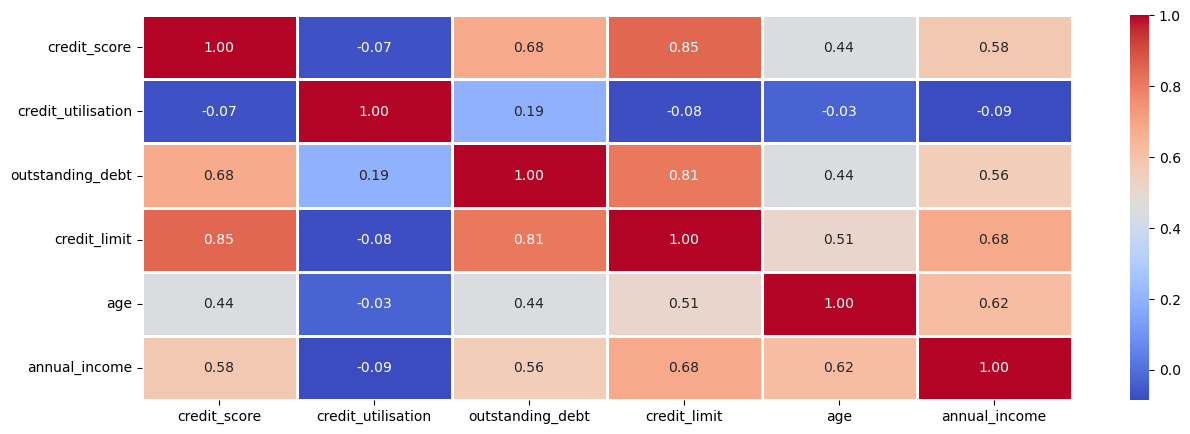

In [427]:
## ploting heatmap for better understaing of correaltion
plt.figure(figsize = (15,5))
sns.heatmap(correlation, annot=True, cmap='coolwarm',fmt=".2f", linewidths= 0.8)
plt.show()

# 3. Preparing Transactions table

In [439]:
df_t.shape

(500000, 7)

In [433]:
## checking duplicate values 
df_t.cust_id.nunique()

1000

In [435]:
## checkinh null values 
df_t[df_t['platform'].isnull()]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
355,356,58,2023-01-01,237,None,Electronics,Net Banking
418,419,383,2023-01-01,338,None,Electronics,Credit Card
607,608,421,2023-01-01,700,None,Electronics,Phonepe
844,845,945,2023-01-01,493,None,Sports,Credit Card
912,913,384,2023-01-01,85,None,Fashion & Apparel,Phonepe
...,...,...,...,...,...,...,...
499579,499580,924,2023-09-05,31,None,Fashion & Apparel,Gpay
499646,499647,944,2023-09-05,58445,None,Fashion & Apparel,Phonepe
499725,499726,620,2023-09-05,15,None,Sports,Net Banking
499833,499834,616,2023-09-05,97,None,Fashion & Apparel,Credit Card


In [437]:
## checking mode for all the product_category
mode_by_product_cat = df_t.groupby('product_category')['platform'].apply(lambda x : x.mode().iloc[0])


In [447]:
##Replacing null values with mode 
df_t.platform.fillna(df_t['platform'].mode()[0],inplace= True)

In [448]:
df_t.isnull().sum()

tran_id             0
cust_id             0
tran_date           0
tran_amount         0
platform            0
product_category    0
payment_type        0
dtype: int64

In [449]:
df_t.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.00000
mean,250000.500000,501.400428,3225.20733
std,144337.711634,288.641924,13098.74276
min,1.000000,1.000000,0.00000
25%,125000.750000,252.000000,64.00000
50%,250000.500000,502.000000,141.00000
75%,375000.250000,752.000000,397.00000
max,500000.000000,1000.000000,69999.00000


In [471]:
df_t1 = df_t[(df_t.platform == 'Amazon')&(df_t.product_category == 'Electronics')&(df_t.payment_type == 'Credit Card')]

In [473]:
df_t1

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
109,110,887,2023-01-01,635,Amazon,Electronics,Credit Card
120,121,440,2023-01-01,0,Amazon,Electronics,Credit Card
141,142,839,2023-01-01,0,Amazon,Electronics,Credit Card
173,174,676,2023-01-01,60439,Amazon,Electronics,Credit Card
190,191,763,2023-01-01,697,Amazon,Electronics,Credit Card
...,...,...,...,...,...,...,...
499812,499813,688,2023-09-05,425,Amazon,Electronics,Credit Card
499860,499861,373,2023-09-05,480,Amazon,Electronics,Credit Card
499885,499886,520,2023-09-05,643,Amazon,Electronics,Credit Card
499928,499929,4,2023-09-05,0,Amazon,Electronics,Credit Card


In [476]:
median_replace = df_t1[df_t1.tran_amount > 0].tran_amount.median()
median_replace

554.0

In [477]:
df_t['tran_amount'].replace(0,median_replace, inplace =True)

In [479]:
df_t.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.000000
mean,250000.500000,501.400428,3230.452602
std,144337.711634,288.641924,13097.561071
min,1.000000,1.000000,2.000000
25%,125000.750000,252.000000,66.000000
50%,250000.500000,502.000000,146.000000
75%,375000.250000,752.000000,413.000000
max,500000.000000,1000.000000,69999.000000


In [500]:
## replacing outliner with IQR 

q1, q3= df_t.tran_amount.quantile([0.25,0.75])

IQR = q3 - q1
lower = q1 - 2*IQR
upper = q3 + 2*IQR

lower, upper

(-628.0, 1107.0)

In [501]:
df_normal = df_t[df_t.tran_amount < 1107]

In [502]:
mean_outliers = round(df_normal.groupby('product_category')['tran_amount'].mean(),2)

In [503]:
mean_outliers 

product_category
Beauty & Personal Care     92.17
Books                      29.55
Electronics               510.17
Fashion & Apparel          64.55
Garden & Outdoor          125.63
Home Decor                302.49
Kitchen Appliances        176.77
Sports                    269.18
Toys & Games               50.33
Name: tran_amount, dtype: float64

In [504]:
df_t['tran_amount'] = df_t.apply(lambda row : mean_outliers[row['product_category']] if row['tran_amount'] > upper else row['tran_amount'], axis= 1)

<Axes: xlabel='tran_amount', ylabel='Count'>

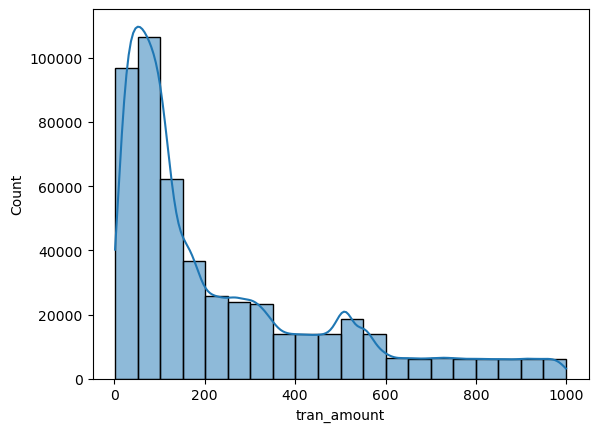

In [509]:
sns.histplot(df_t.tran_amount, kde = True, bins= 20)

In [513]:
Merged = df_merged.merge(df_t , on = 'cust_id', how = 'inner')

In [514]:
Merged

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,...,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,tran_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,Manya Acharya,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,...,19571.0,0.0,40000.0,700-749,1283,2023-01-01,30.0,Shopify,Fashion & Apparel,Net Banking
1,1,Manya Acharya,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,...,19571.0,0.0,40000.0,700-749,1382,2023-01-01,96.0,Amazon,Sports,Debit Card
2,1,Manya Acharya,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,...,19571.0,0.0,40000.0,700-749,1521,2023-01-01,86.0,Meesho,Garden & Outdoor,Gpay
3,1,Manya Acharya,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,...,19571.0,0.0,40000.0,700-749,1576,2023-01-01,149.0,Amazon,Beauty & Personal Care,Phonepe
4,1,Manya Acharya,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,...,19571.0,0.0,40000.0,700-749,1757,2023-01-01,37.0,Flipkart,Fashion & Apparel,Credit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,1000,Akshay Choudhary,Male,28.0,City,Freelancer,226873.0,Married,26-48,775,...,33956.0,1.0,60000.0,750-800,495592,2023-09-03,63.0,Shopify,Fashion & Apparel,Gpay
499996,1000,Akshay Choudhary,Male,28.0,City,Freelancer,226873.0,Married,26-48,775,...,33956.0,1.0,60000.0,750-800,495907,2023-09-03,743.0,Alibaba,Electronics,Phonepe
499997,1000,Akshay Choudhary,Male,28.0,City,Freelancer,226873.0,Married,26-48,775,...,33956.0,1.0,60000.0,750-800,496570,2023-09-04,20.0,Cred,Books,Credit Card
499998,1000,Akshay Choudhary,Male,28.0,City,Freelancer,226873.0,Married,26-48,775,...,33956.0,1.0,60000.0,750-800,497591,2023-09-04,558.0,Alibaba,Home Decor,Net Banking


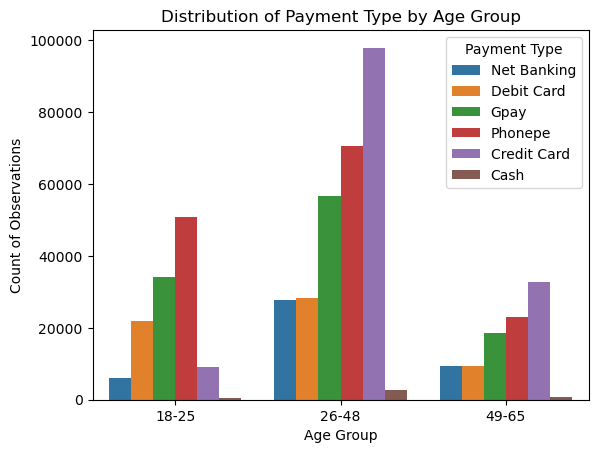

In [522]:
sns.countplot(x='age_group', hue='payment_type', data=Merged)
plt.title("Distribution of Payment Type by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count of Observations")
plt.legend(title="Payment Type", loc="upper right")
plt.show()

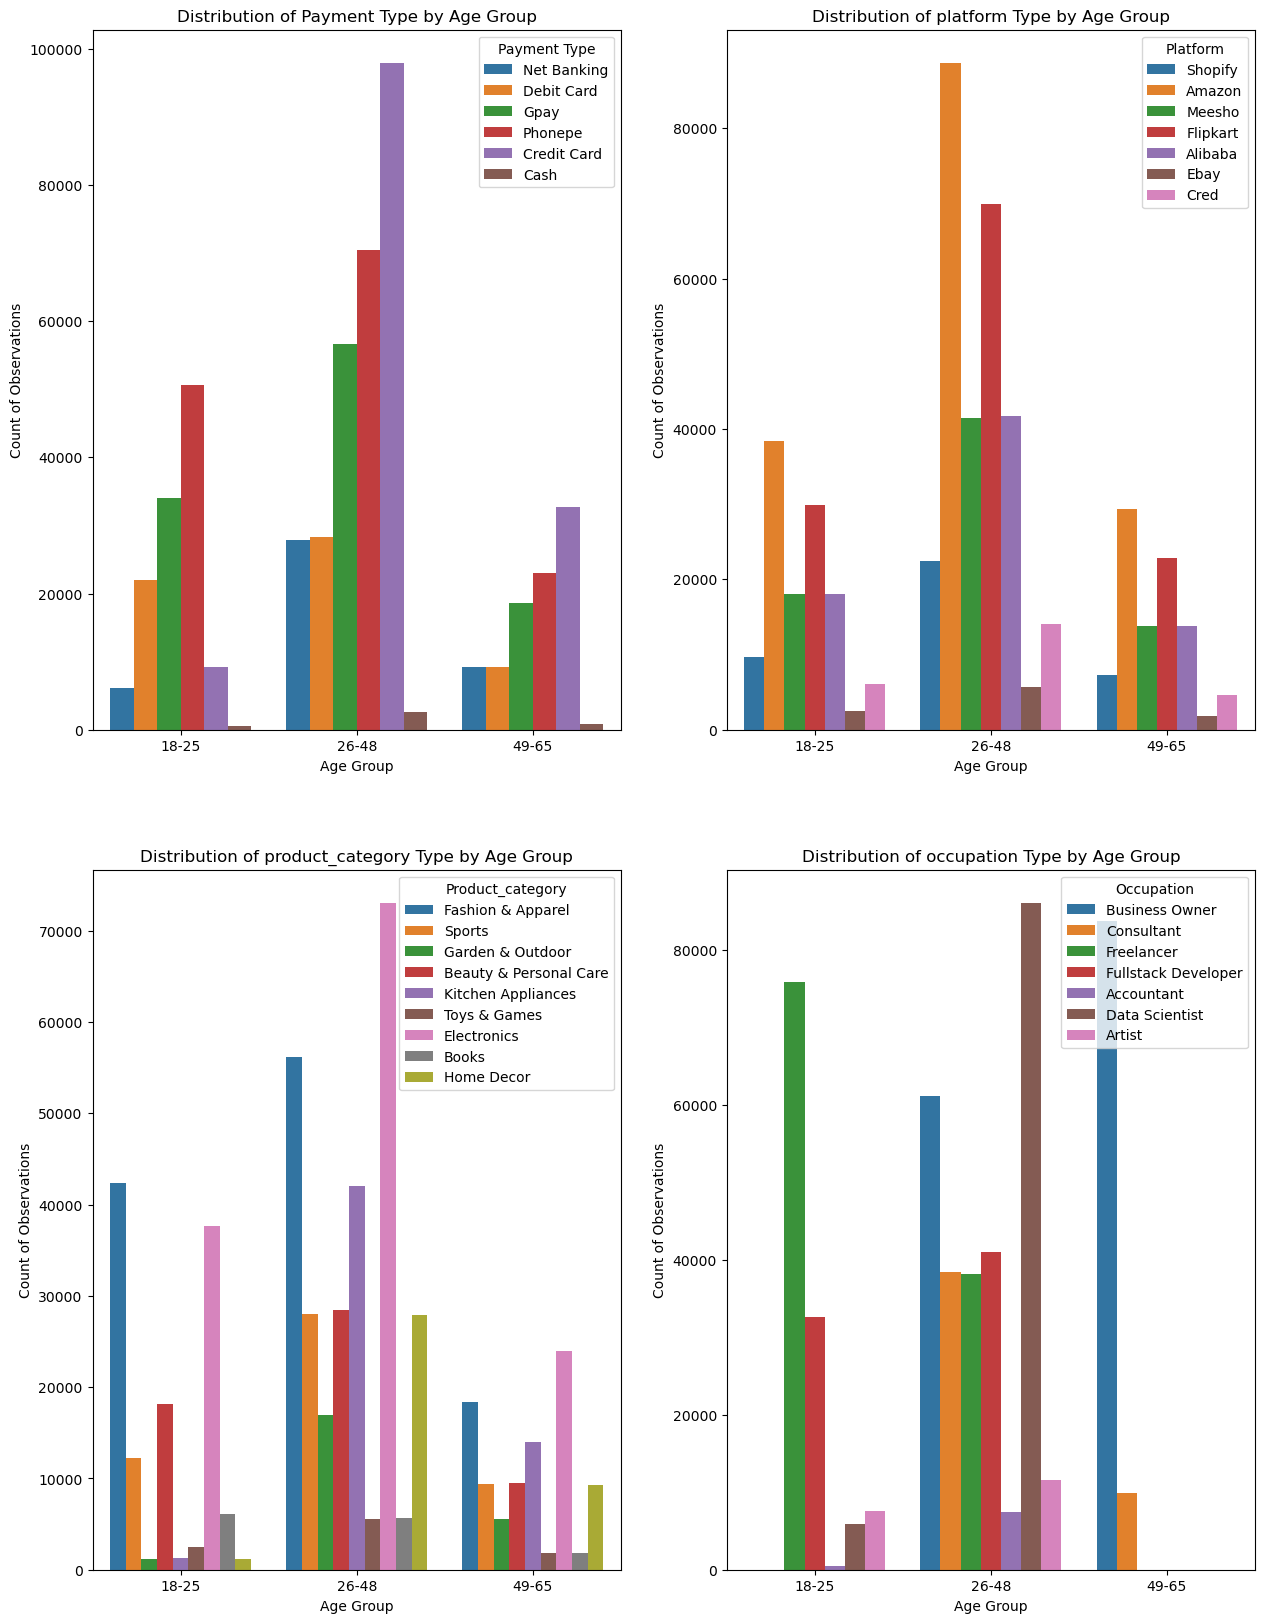

In [542]:
fig,((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize= (15,20))

## ax1 

sns.countplot(x='age_group', hue='payment_type', data=Merged, ax= ax1)
ax1.set_title("Distribution of Payment Type by Age Group")
ax1.set_xlabel("Age Group")
ax1.set_ylabel("Count of Observations")
ax1.legend(title="Payment Type", loc="upper right")

##ax2

sns.countplot(x='age_group', hue='platform', data=Merged, ax= ax2)
ax2.set_title("Distribution of platform Type by Age Group")
ax2.set_xlabel("Age Group")
ax2.set_ylabel("Count of Observations")
ax2.legend(title="Platform", loc="upper right")

##ax3


sns.countplot(x='age_group', hue='product_category', data=Merged, ax= ax3)
ax3.set_title("Distribution of product_category Type by Age Group")
ax3.set_xlabel("Age Group")
ax3.set_ylabel("Count of Observations")
ax3.legend(title="Product_category", loc="upper right")


##ax4

sns.countplot(x='age_group', hue='occupation', data=Merged, ax= ax4)
ax4.set_title("Distribution of occupation Type by Age Group")
ax4.set_xlabel("Age Group")
ax4.set_ylabel("Count of Observations")
ax4.legend(title="Occupation", loc="upper right")

plt.show()